## 1. Importing required libraries

In [ ]:
import numpy as np
import pandas as pd
import os
import warnings
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.pipeline import Pipeline


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

from google.colab import files


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Dataset load and explore

In [7]:

uploaded = files.upload()


df = pd.read_csv("Crop_recommendation.csv")




print("\n" + "="*80)
print("Dataset Statistics:")
print(df.describe())

print("\n" + "="*80)
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*80)
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "="*80)
print("Crop Distribution:")
print(df['label'].value_counts())

Saving Crop_recommendation.csv to Crop_recommendation.csv

Dataset Statistics:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.9236

In [8]:

X = df.drop('label', axis=1)
y = df['label']


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label Encoding Mapping:")
for idx, crop in enumerate(label_encoder.classes_):
    print(f"  {crop}: {idx}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Feature dimensions: {X_train.shape[1]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled")

Label Encoding Mapping:
  apple: 0
  banana: 1
  blackgram: 2
  chickpea: 3
  coconut: 4
  coffee: 5
  cotton: 6
  grapes: 7
  jute: 8
  kidneybeans: 9
  lentil: 10
  maize: 11
  mango: 12
  mothbeans: 13
  mungbean: 14
  muskmelon: 15
  orange: 16
  papaya: 17
  pigeonpeas: 18
  pomegranate: 19
  rice: 20
  watermelon: 21

Training set size: 1760 samples
Testing set size: 440 samples
Feature dimensions: 7

Features scaled


# Model traingin and evaluation
### XGBoost - gradient boosting; handles non-linear patterns; fast
Random Forest - Robust to overfitting; built-in feature importance; interpretable

#### 6.1 K-Nearest Neighbors Classifier

In [9]:
print("Training K-Nearest Neighbors Classifier...\n")

# Optimized KNN
knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print("="*80)
print("K-NEAREST NEIGHBORS PERFORMANCE METRICS")
print("="*80)
print(f"Training Accuracy: {knn_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")

Training K-Nearest Neighbors Classifier...

K-NEAREST NEIGHBORS PERFORMANCE METRICS
Training Accuracy: 1.0000
Testing Accuracy: 0.9818
Precision (weighted): 0.9829
Recall (weighted): 0.9818
F1-Score (weighted): 0.9817


#### 6.2 Support Vector Machine

In [10]:
print("Training Support Vector Machine...\n")

# SVM with RBF kernel
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=RANDOM_STATE
)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("="*80)
print("SUPPORT VECTOR MACHINE PERFORMANCE METRICS")
print("="*80)
print(f"Training Accuracy: {svm_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

Training Support Vector Machine...

SUPPORT VECTOR MACHINE PERFORMANCE METRICS
Training Accuracy: 0.9932
Testing Accuracy: 0.9886
Precision (weighted): 0.9896
Recall (weighted): 0.9886
F1-Score (weighted): 0.9887


#### 6.3 Decision Tree Classifier

In [11]:
print("Training Decision Tree Classifier...\n")

# Optimized Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE
)

dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("="*80)
print("DECISION TREE PERFORMANCE METRICS")
print("="*80)
print(f"Training Accuracy: {dt_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")

Training Decision Tree Classifier...

DECISION TREE PERFORMANCE METRICS
Training Accuracy: 0.9830
Testing Accuracy: 0.9659
Precision (weighted): 0.9669
Recall (weighted): 0.9659
F1-Score (weighted): 0.9659


#### 6.4 Random Forest Classifier

In [ ]:

print("Training Random Forest Classifier with GridSearchCV...\n")


rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}


rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)


rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


rf_grid_search.fit(X_train_scaled, y_train)


rf_model = rf_grid_search.best_estimator_

print("\n" + "="*80)
print("Best Random Forest Parameters:")
for param, value in rf_grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Score: {rf_grid_search.best_score_:.4f}")


y_pred_rf = rf_model.predict(X_test_scaled)


print("\n" + "="*80)
print("RANDOM FOREST PERFORMANCE METRICS")
print("="*80)
print(f"Training Accuracy: {rf_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")


print("\n" + "="*80)
print("RANDOM FOREST - DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Random Forest - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

#### 6.5 Gradient Boosting  Classifier

In [14]:
print("Training Gradient Boosting Classifier...\n")

# Optimized Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

print("="*80)
print("GRADIENT BOOSTING PERFORMANCE METRICS")
print("="*80)
print(f"Training Accuracy: {gb_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_gb, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_gb, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_gb, average='weighted'):.4f}")

print("\n" + "="*80)
print("GRADIENT BOOSTING - CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_gb, target_names=label_encoder.classes_))

Training Gradient Boosting Classifier...

GRADIENT BOOSTING PERFORMANCE METRICS
Training Accuracy: 1.0000
Testing Accuracy: 0.9864
Precision (weighted): 0.9875
Recall (weighted): 0.9864
F1-Score (weighted): 0.9864

GRADIENT BOOSTING - CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      0.95      0.97        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1

#### 6.6 XGBoost Classifier

In [ ]:
pipe_xgb = Pipeline([
    ('xgb', XGBClassifier(eval_metric='mlogloss', random_state=42))
])

param_grid_xgb = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 6],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample': [0.8, 1],
    'xgb__colsample_bytree': [0.8, 1]
}

grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print(f"Best XGB Params: {grid_xgb.best_params_}")


y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb = best_xgb.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred_xgb)
test_acc = accuracy_score(y_test, y_test_pred_xgb)

precision = precision_score(y_test, y_test_pred_xgb, average='weighted')
recall = recall_score(y_test, y_test_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_test_pred_xgb, average='weighted')

print("\n" + "="*60)
print("XGBOOST PERFORMANCE METRICS")
print("="*60)
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")



###  Model Comparision


MODEL PERFORMANCE COMPARISON
            Model  Accuracy  Precision   Recall  F1-Score
          XGBoost  0.993182   0.993398 0.993182  0.993179
              SVM  0.990909   0.991342 0.990909  0.990903
Gradient Boosting  0.990909   0.991234 0.990909  0.990905
         LightGBM  0.990909   0.991234 0.990909  0.990905
    Random Forest  0.988636   0.989742 0.988636  0.988595
    Decision Tree  0.975000   0.976661 0.975000  0.975223
              KNN  0.972727   0.973603 0.972727  0.972400


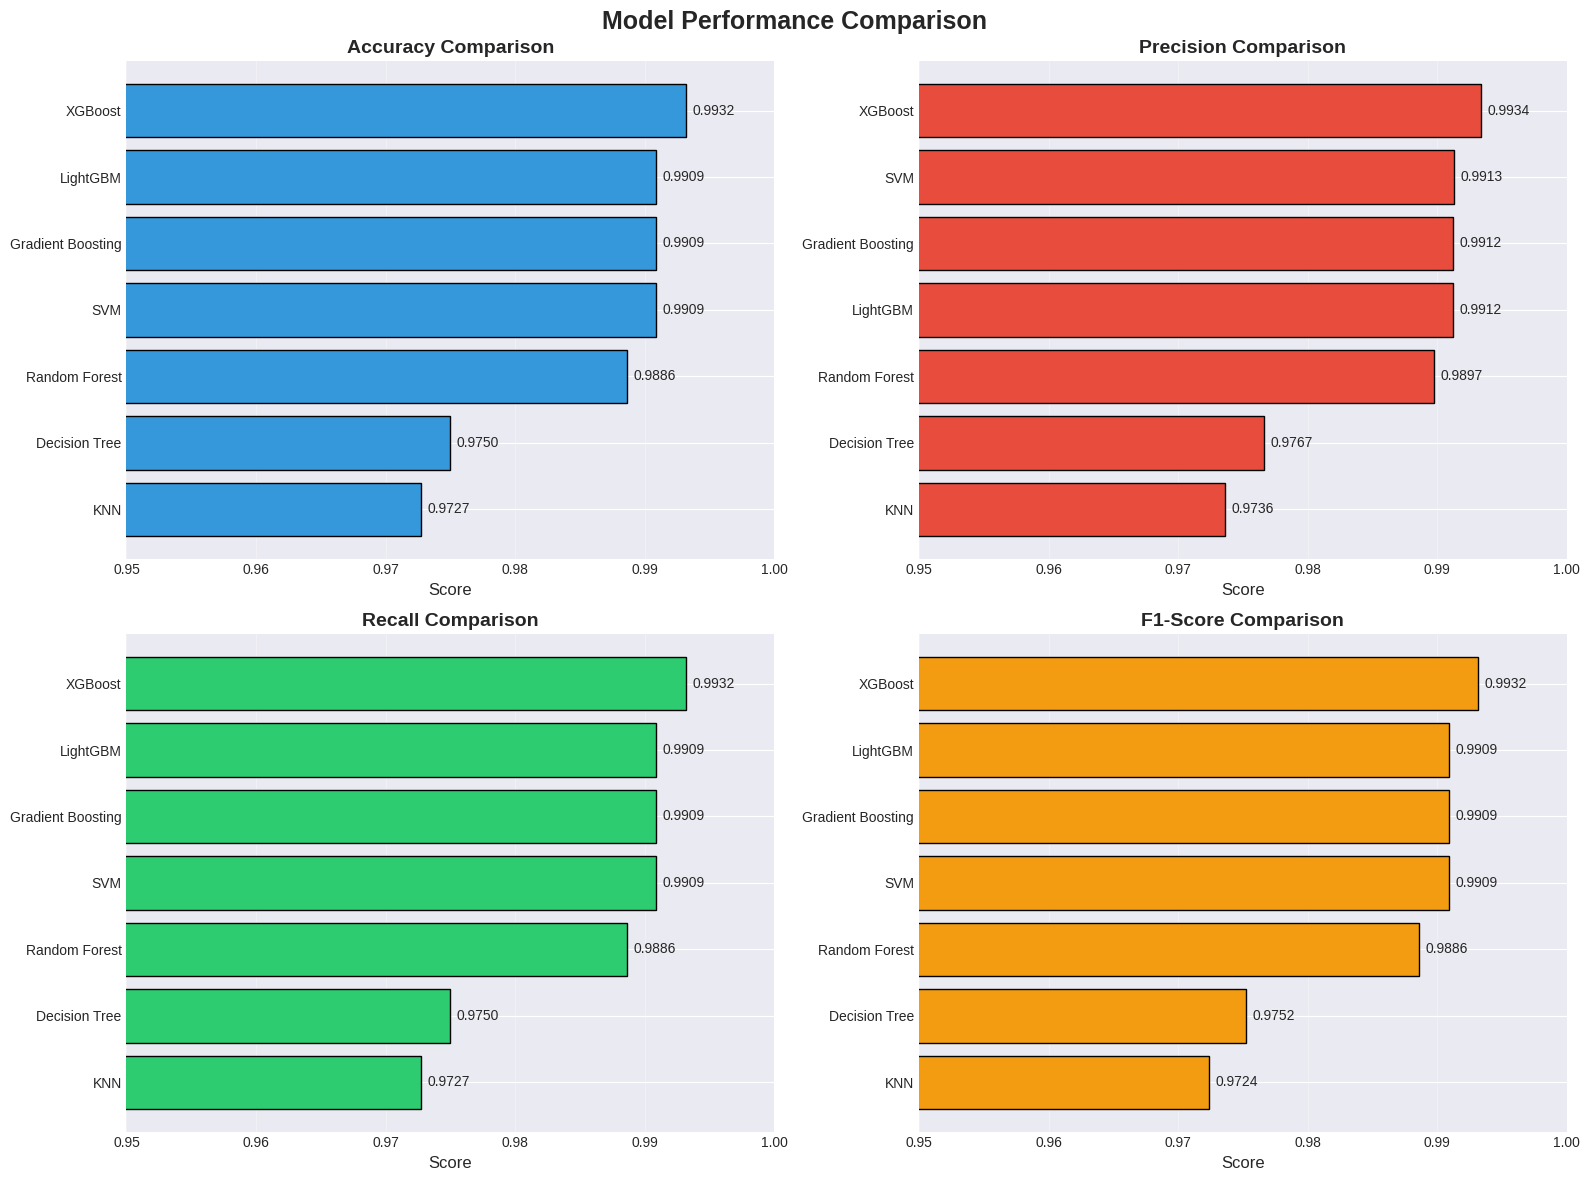

In [ ]:

models_performance = pd.DataFrame({
    'Model': [
        'Random Forest', 'Gradient Boosting', 'Decision Tree',
        'KNN', 'SVM', 'XGBoost', 'LightGBM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_test_pred_xgb),
        accuracy_score(y_test, y_test_pred_lgbm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_gb, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted'),
        precision_score(y_test, y_test_pred_xgb, average='weighted'),
        precision_score(y_test, y_test_pred_lgbm, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_gb, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_test_pred_xgb, average='weighted'),
        recall_score(y_test, y_test_pred_lgbm, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_gb, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_test_pred_xgb, average='weighted'),
        f1_score(y_test, y_test_pred_lgbm, average='weighted')
    ]
}).sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(models_performance.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for ax, metric, color in zip(axes.ravel(), metrics, colors):

    models_sorted = models_performance.sort_values(metric, ascending=True)

    bars = ax.barh(
        models_sorted['Model'],
        models_sorted[metric],
        color=color,
        edgecolor='black'
    )

    ax.set_xlabel('Score', fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim([0.95, 1.0])
    ax.grid(axis='x', alpha=0.3)


    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', va='center', fontsize=10)

plt.suptitle("Model Performance Comparison", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import os
import joblib

os.makedirs('model', exist_ok=True)

print("Saving models and preprocessors...\n")

models_to_save = {
    'rf_model.pkl': rf_model,
    'gb_model.pkl': gb_model,
    'dt_model.pkl': dt_model,
    'knn_model.pkl': knn_model,
    'svm_model.pkl': svm_model,
    'ensemble_model.pkl': ensemble_model,
    'xgb_model.pkl': best_xgb,
    'lgbm_model.pkl': best_lgbm,
}

for filename, model in models_to_save.items():
    try:
        joblib.dump(model, f'model/{filename}')
        print(f"✓ Saved: model/{filename}")
    except Exception as e:
        print(f"Error saving {filename}: {e}")


joblib.dump(label_encoder, 'model/label_encoder.pkl')
print("✓ Saved: model/label_encoder.pkl")

joblib.dump(scaler, 'model/scaler.pkl')
print("✓ Saved: model/scaler.pkl")


feature_names = X.columns.tolist()
joblib.dump(feature_names, 'model/feature_names.pkl')
print("✓ Saved: model/feature_names.pkl")


print("\nAll models and preprocessors saved successfully!")

Saving models and preprocessors...

✓ Saved: model/rf_model.pkl
✓ Saved: model/gb_model.pkl
✓ Saved: model/dt_model.pkl
✓ Saved: model/knn_model.pkl
✓ Saved: model/svm_model.pkl
✓ Saved: model/ensemble_model.pkl
✓ Saved: model/xgb_model.pkl
✓ Saved: model/lgbm_model.pkl
✓ Saved: model/label_encoder.pkl
✓ Saved: model/scaler.pkl
✓ Saved: model/feature_names.pkl

All models and preprocessors saved successfully!
